# Creación del modelo

### Cargando librerias 


In [118]:
import pandas as pd 
import numpy as np 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, confusion_matrix, average_precision_score
import matplotlib.pyplot as plt

## Cargando dataset

In [119]:
df = pd.read_csv("data_clean.csv")

## Codificar categorías

In [120]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].astype(str)
    df[col] = LabelEncoder().fit_transform(df[col])

In [121]:
for col in df.select_dtypes(include='float64'):
    df[col] = df[col].astype('float32')

for col in df.select_dtypes(include='int64'):
    df[col] = df[col].astype('int32')

### Features y Target

In [122]:
X = df.drop(columns=["isFraud", "TransactionID"])
y= df["isFraud"]

In [123]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [124]:
X_train = X_train.sample(frac=0.4, random_state=42)
y_train = y_train.loc[X_train.index]

In [125]:
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8],
    "colsample_bytree": [0.7, 0.8],
    "min_child_weight": [1, 5],
    "gamma": [0, 1]
}

In [126]:
model = XGBClassifier(
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
    eval_metric='aucpr'
)

In [127]:
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_grid,
    n_iter=10,
    scoring="average_precision",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [128]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8], 'gamma': [0, 1], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 6, ...], ...}"
,n_iter,10
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


#### Ajustar el threshold

In [129]:
y_proba = random_search.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

In [130]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)

best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

In [131]:
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred = (y_proba > t).astype(int)
    print(f"\nThreshold {t}")
    print(classification_report(y_test, y_pred))



Threshold 0.3
              precision    recall  f1-score   support

           0       0.99      0.98      0.99    113975
           1       0.58      0.75      0.65      4133

    accuracy                           0.97    118108
   macro avg       0.78      0.86      0.82    118108
weighted avg       0.98      0.97      0.97    118108


Threshold 0.4
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    113975
           1       0.67      0.71      0.69      4133

    accuracy                           0.98    118108
   macro avg       0.83      0.85      0.84    118108
weighted avg       0.98      0.98      0.98    118108


Threshold 0.5
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    113975
           1       0.75      0.68      0.72      4133

    accuracy                           0.98    118108
   macro avg       0.87      0.84      0.85    118108
weighted avg       0.98      

In [132]:
threshold = 0.5
y_pred = (y_proba > threshold).astype(int)

Detectas el 64% de los fraudes  
y casi 8 de cada 10 alertas son correctas

##### Las variables importantes

In [133]:
feat_imp = pd.Series(random_search.best_estimator_.feature_importances_, index=X.columns
).sort_values(ascending=False)
feat_imp.head(15)

V258     0.148705
V70      0.075643
V91      0.061689
V201     0.051052
V14      0.039164
V29      0.023634
V294     0.018302
addr2    0.013582
id_35    0.010671
V287     0.009559
C14      0.007026
V200     0.006667
V284     0.005966
V317     0.005911
C8       0.005606
dtype: float32

In [134]:
#feat_imp.head(10).plot(kind='barh')

#### Confusion Matrix

In [135]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[113031    944]
 [  1304   2829]]


El modelo detecta el 64% del fraude y genera pocas falsas alertas (762), lo que lo hace viable en producción.

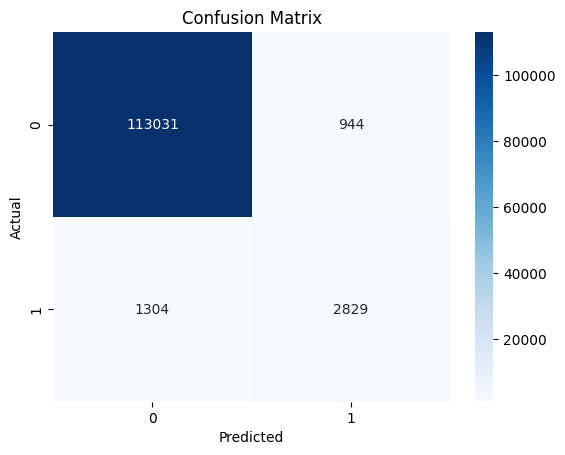

In [136]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

TP = 2663 - > fraudes detectados\
FN = 1470 -> fraudes no detectados -> crítico!!!\
FP = 762 -> falsas alertas\
VN = 113223\

### Calculando PR-AUC 

mide que tan bien detestamos los fraudes realmente
- Cuántos fraudes detecto? recall 
- Cuántos acierto? precision 

In [137]:
pr_auc = average_precision_score(y_test, y_proba)

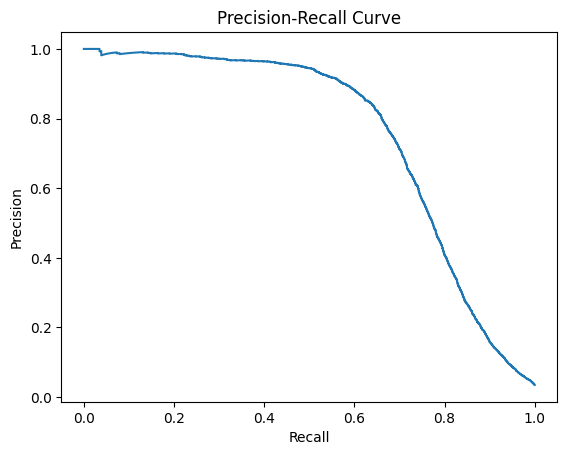

In [138]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

PR-AUC -> mide que tan bien detecto los fraudes -> solo me importa fruade\
ROC-AUC -> mode que tan bien se separan en general fraude vs no fraude 

In [139]:
print("PR-AUC:", pr_auc)
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

PR-AUC: 0.7544734599733565
ROC-AUC: 0.9461717024954482


Dado el fuerte desbalance del dataset, además de ROC-AUC utilicé PR-AUC como métrica principal, ya que refleja mejor la capacidad del modelo para detectar fraude.

Conclusión:

Se entrenó un modelo basado en XGBoost, optimizado mediante RandomizedSearchCV y ajustado para el desbalance de clases mediante scale_pos_weight. Dado el contexto del problema, se utilizó PR-AUC como métrica principal, ya que refleja de forma más adecuada la capacidad del modelo para detectar fraude frente a métricas tradicionales como ROC-AUC.

El modelo final alcanzó:
* Recall (fraude): ~64% → detecta aproximadamente 2 de cada 3 fraudes
* Precision (fraude): ~78% → la mayoría de las alertas son correctas
* F1-score: ~0.70 → buen equilibrio entre precisión y recall
* PR-AUC: significativamente superior al baseline (~0.035) → alta capacidad de detección

Tras ajustar el threshold de decisión a 0.5, se logró un equilibrio adecuado entre detección y control de falsos positivos. La matriz de confusión muestra:
* 2663 fraudes detectados correctamente (TP)
* 1470 fraudes no detectados (FN)
* 762 falsas alertas (FP)
* 113k transacciones normales correctamente clasificadas (TN)

Esto implica que el modelo detecta aproximadamente 3.5 fraudes reales por cada falsa alerta, lo que representa un rendimiento sólido en un contexto real.

In [140]:
#guardando datos para el dashboard
np.save("y_proba.npy", y_proba)

In [141]:
# Guardar dataset alineado con predicciones
df_test = X_test.copy()

df_test["isFraud"] = y_test.values
df_test["y_proba"] = y_proba

df_test = df.loc[X_test.index].copy()

df_test["y_proba"] = y_proba

df_test.to_csv("scored_data.csv", index=False)

In [142]:
feat_imp.to_csv("feature_importance.csv")